In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

# Reading the permafrost files from CEDA archive

In [ ]:
target_path = r'/neodc/esacci/permafrost/data/permafrost_extent/L4/area4/pp/v04.0'

# Verifies the file path actually exists:
# If no -> prints an error message
# If yes -> creates an array of file names in the dir, prints the number of files found, 
# then adds the target path to the start of each file name

if not os.path.exists(target_path):
    print(f"Error: The path {target_path} does not exist on this machine.")
    
else:
	permafrost_extent_files = np.array(os.listdir(target_path))
	
	print(f"Successfully found {len(permafrost_extent_files)} files in the target directory.")
	
	permafrost_extent_files = np.strings.add(target_path + '/', permafrost_extent_files[1:])

    

# Opens the first dataset (for 1997), then converts it to a data array
# Potentially build a function that reads out a number of files into an array of data arrays based on a 
# user input number of years. Could extend this further to allow a user to input a source path and run
# the above code first to generalise it for any data source available through JASMIN/ALICE or locally.

permafrost_extent_1997 = xr.open_dataset(permafrost_extent_files[0])

permafrost_fraction = xr.DataArray(
permafrost_extent_1997['PFR'],
dims=('time', 'lat', 'lon'),
coords={'time': permafrost_extent_1997['time'], 'lon': permafrost_extent_1997['lon'], 'lat': permafrost_extent_1997['lat']},
name='PFR',
attrs={'units': 'Percentage', 'long_name': 'Permafrost Area Fraction'},
)

# Slices the array based on latitude (includes +50 to +90 degs), then selects the time (1997)

permafrost_fraction_arctic_1997 = permafrost_fraction.sel(lat=slice(50.0, 90.0))

#permafrost_fraction_arctic_1997 = permafrost_fraction_arctic_1997.isel(time = 0)

Successfully found 26 files in the target directory.


Text(0.5, 1.0, 'Permafrost Extent 1997')

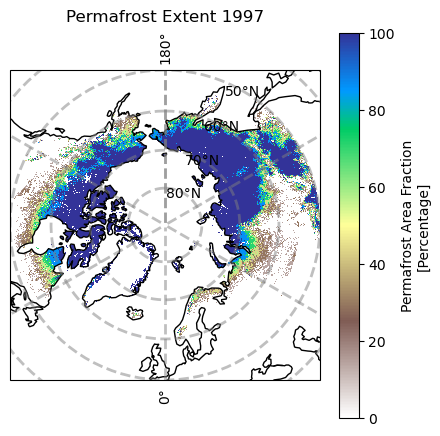

In [6]:
fig = plt.figure(figsize=(5, 5))              
ax = plt.axes(projection=ccrs.NorthPolarStereo())  
permafrost_fraction_arctic_1997.plot(ax=ax, transform=ccrs.PlateCarree(), cmap = 'terrain_r') 
ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
ax.coastlines()                                    
ax.set_title('Permafrost Extent 1997')